In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Line Plot

Useful when you have a numerical (usually time) axis and each time is associated with exactly one output

In [2]:
popfull = Table.read_table('nc-est2019-agesex-res.csv')
popfull.show(10)

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323
0,5,4056858,4056872,4064521,4087054,4131049,4121876,4004576,4017589,4035033,4003452,4008443,4028281
0,6,4066381,4066412,4072904,4074531,4096631,4141126,4133372,4017388,4031568,4048018,4014057,4017227
0,7,4030579,4030594,4042990,4082821,4084175,4106756,4152666,4145872,4030888,4044139,4058370,4022319
0,8,4046486,4046497,4025501,4052773,4092559,4094513,4118349,4165033,4158848,4042924,4054236,4066194
0,9,4148353,4148369,4125312,4035319,4062726,4103052,4106068,4130887,4177895,4170813,4053179,4061874


Goal: Visualize 2019 US population (y-axis) as a function of age (x-axis) on a line plot.
Cleanup steps:
- Select all rows where SEX is 0 (this aggregates all sex categories)
- Throw away row where AGE is 999 (this row aggregates all age categories)
- Select just the AGE (x-axis) and POPESTIMATE2019 columns (y-axis)

In [3]:
pop2019 = popfull.where('SEX', 0).where('AGE', are.below(999)).select("AGE", "POPESTIMATE2019")
pop2019.show(10)

AGE,POPESTIMATE2019
0,3783052
1,3829599
2,3922044
3,3998665
4,4043323
5,4028281
6,4017227
7,4022319
8,4066194
9,4061874


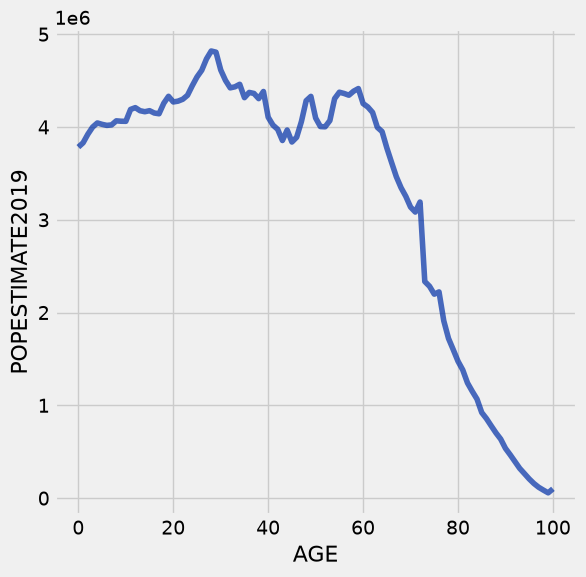

In [4]:
# First argument is the column for x-axis
# Second argument is the column for the y-axis
pop2019.plot('AGE', 'POPESTIMATE2019')

In [6]:
# Let's compare male and female counts per age
males2019 = popfull.where('SEX', 1).where('AGE', are.below(999)).select("AGE", "POPESTIMATE2019")
females2019 = popfull.where('SEX', 2).where('AGE', are.below(999)).select("AGE", "POPESTIMATE2019")
males2019.show(3)
females2019.show(3)

AGE,POPESTIMATE2019
0,1935117
1,1958585
2,2005544


AGE,POPESTIMATE2019
0,1847935
1,1871014
2,1916500


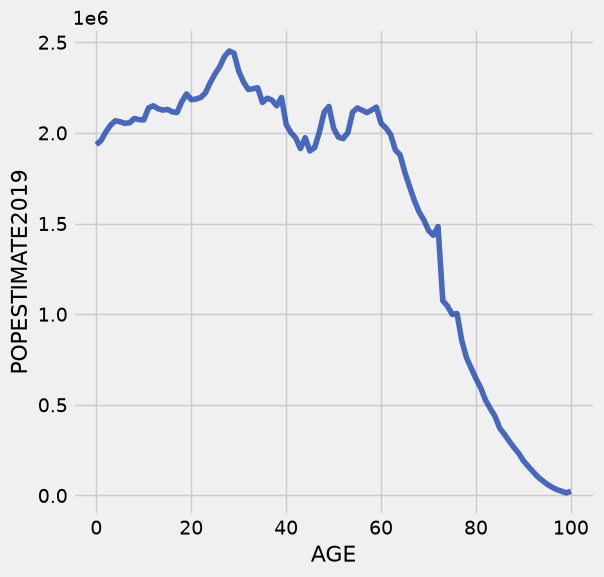

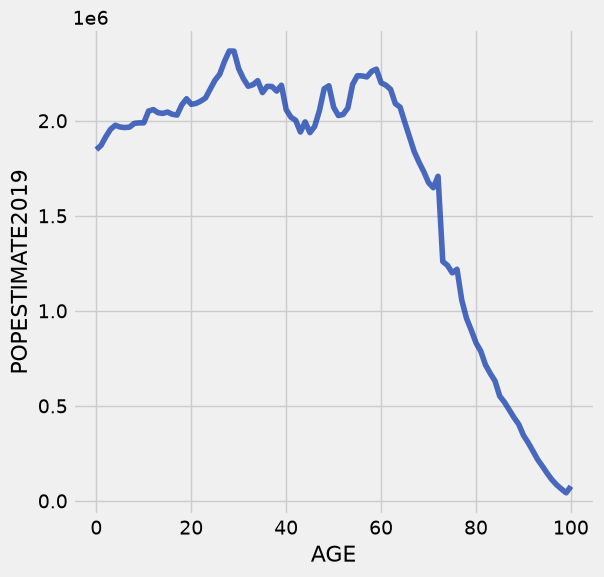

In [15]:
males2019.plot('AGE', 'POPESTIMATE2019')
females2019.plot('AGE', 'POPESTIMATE2019')

In [16]:
# Put everything in one table to plot
# Table() creates a blank table with no data
# with_columns adds the requested columns
pop_2019_mf = Table().with_columns(
    'Age', males2019.column('AGE'),
    'Males', males2019.column('POPESTIMATE2019'),
    'Females', females2019.column('POPESTIMATE2019')
)
pop_2019_mf.show(5)

Age,Males,Females
0,1935117,1847935
1,1958585,1871014
2,2005544,1916500
3,2043010,1955655
4,2066951,1976372


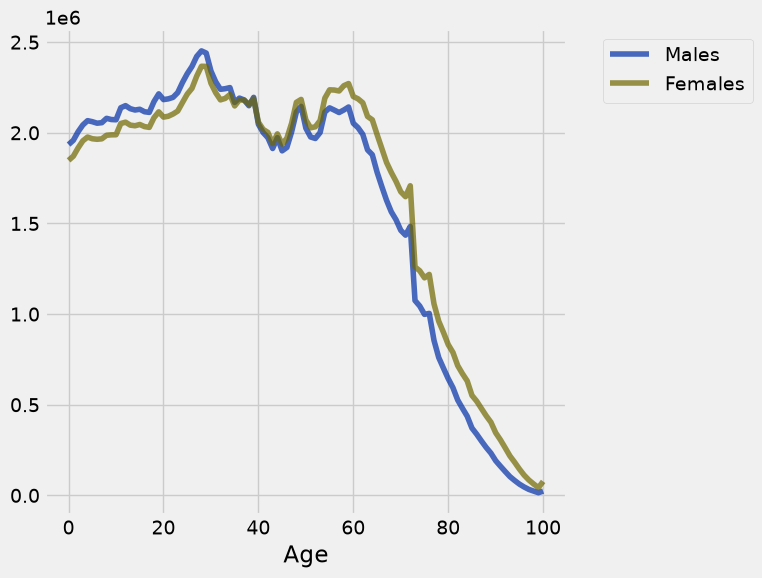

In [12]:
# If only one argument is provided, all other columns are assumed to be y-axis data for separate plots
pop_2019_mf.plot('Age')

# Practice
Create a line plot where
* x-axis is age
* y-axis is the percent of people in 2018 registered as female at each age

Try getting an array for the numerator and the denominator separately.

Numerator
* Filter the popfull table down to entries where sex is set to 2 and age is below 999, then select the columns you need.

Demoninator
* Filter the popfull table down to entries where sex is set to 0 and age is below 999, then select the columns you need.

Strip off the relevant columns and do the array arithmetic to get a percent.

AGE,POPESTIMATE2018
0,1863680
1,1909808
2,1949783


AGE,POPESTIMATE2018
0,3815343
1,3908830
2,3987032


[ 0.48846984  0.48858815  0.48903119  0.48875042  0.48828694  0.4889512
  0.48892081  0.48856019  0.4896449   0.48980763  0.48961295  0.48914619
  0.48910072  0.48954652  0.4899215   0.49015579  0.4900644   0.489588
  0.48856166  0.48860136  0.48865108  0.48917836  0.48799992  0.48711383
  0.48704406  0.48638018  0.48798323  0.49073832  0.492019    0.49238977
  0.49303829  0.49321295  0.49367854  0.49537614  0.49746012  0.49854511
  0.49960907  0.50046118  0.49868072  0.50111912  0.50177853  0.5033931
  0.50328133  0.50233083  0.50441434  0.50611348  0.50544678  0.50581162
  0.50397901  0.50509877  0.50575125  0.50744841  0.50743455  0.50814512
  0.51053173  0.51181285  0.51275655  0.51427686  0.51354359  0.51610694
  0.51760676  0.51960873  0.52161181  0.52278953  0.52589133  0.52740858
  0.52841884  0.53073147  0.53073752  0.53204195  0.53246045  0.53309457
  0.53733844  0.54025559  0.54331261  0.545667    0.54976976  0.55507399
  0.5582241   0.56002504  0.56630388  0.57203567  0.578

AGE,Percent Female
0,0.48847
1,0.488588
2,0.489031
3,0.48875
4,0.488287


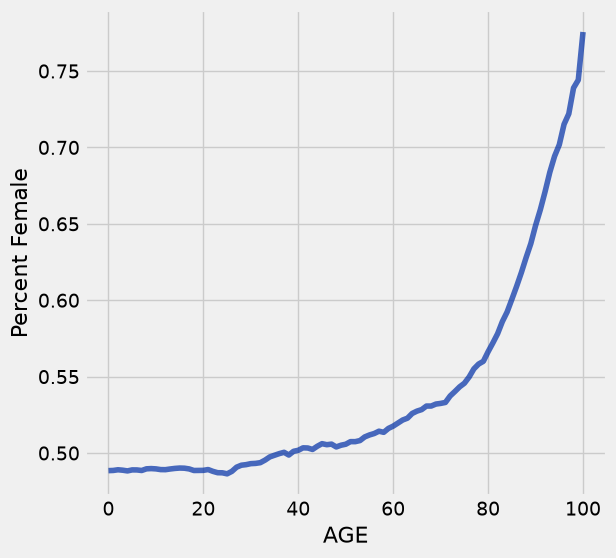

In [33]:
female_pop_tbl = popfull.where('SEX', 2).where('AGE', are.below(999)).select('AGE', 'POPESTIMATE2018')
female_pop_tbl.show(3)
total_pop_tbl = popfull.where('SEX', 0).where('AGE', are.below(999)).select('AGE', 'POPESTIMATE2018')
total_pop_tbl.show(3)

female_pop_array = female_pop_tbl.column('POPESTIMATE2018')
total_pop_array = total_pop_tbl.column('POPESTIMATE2018')
#print(female_pop_array)
#print(total_pop_array)

#array arithmetic
percent_array = female_pop_array / total_pop_array
print(percent_array)

age_array = female_pop_tbl.column('AGE')

percent_tbl = Table().with_columns('AGE', age_array, 'Percent Female', percent_array)
percent_tbl.show(5)

percent_tbl.plot('AGE', 'Percent Female')

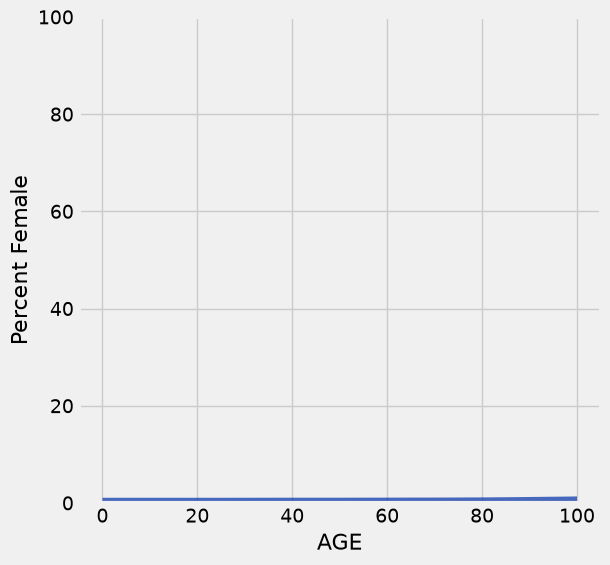

In [36]:
# ^^ Look at the y-axis! Trend is not as dramatic as you might think

# PLOT GOES HERE
percent_tbl.plot('AGE','Percent Female')
plots.ylim(0, 100);  # Optional for Data 8

## Scatter Plots ##

Useful when you have numerical input axis, but each input may have multiple outputs

In [37]:
# Actors and their highest grossing movies
actors = Table.read_table('actors.csv')
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


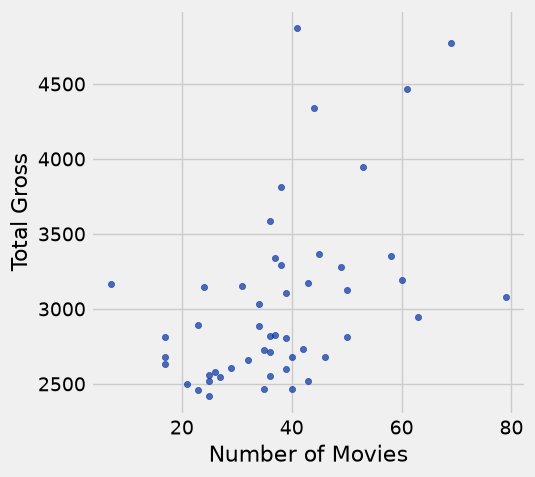

In [40]:
# First argument is x-axis, second argument is y-axis
actors.scatter('Number of Movies', 'Total Gross')

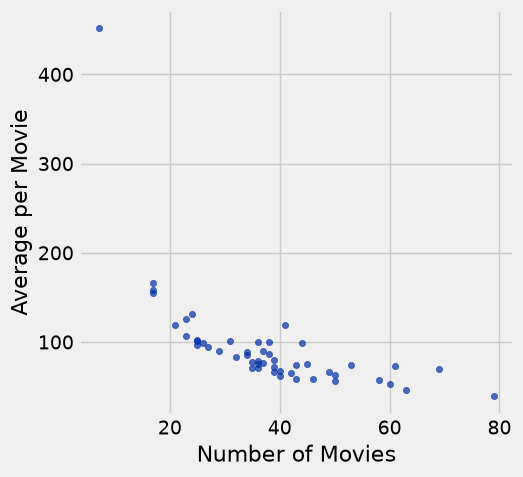

In [41]:
actors.scatter('Number of Movies', 'Average per Movie')

# Practice
Create a scatter plot where
* x-axis is number of movies
* y-axis is the percent each actor's #1 movie represents as a percent of their total gross (e.g., the value corresponding to Harrison Ford should be 936.7 / 4871.7 * 100)

[ 0.02438574  0.01449883  0.01640445  0.02273774  0.01887366  0.0263227
  0.02776539  0.02223476  0.01724601  0.02702622  0.02632058  0.0204007
  0.01668025  0.02324409  0.14284359  0.03224987  0.0416627   0.02000704
  0.02564928  0.012657    0.02942244  0.01586978  0.04348578  0.029424
  0.02702511  0.02778172  0.058811    0.01999432  0.02565475  0.02379995
  0.02857352  0.02776857  0.05883888  0.02174318  0.02499161  0.03126644
  0.05883693  0.03447085  0.02563117  0.03847942  0.03999687  0.02776688
  0.03705013  0.02327426  0.03998729  0.04763428  0.02500304  0.02858767
  0.04349418  0.04001655]


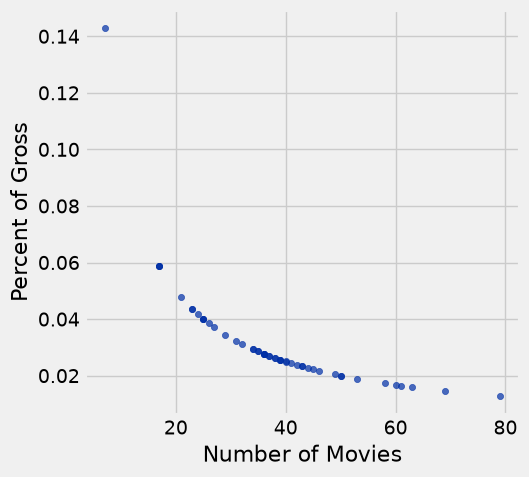

In [51]:
average_per_movie_array = actors.column('Average per Movie')
total_gross_array = actors.column('Total Gross')
percent_of_total_gross_array = average_per_movie_array / total_gross_array
print(percent_of_total_gross_array)

number_of_movies_array = actors.column('Number of Movies')

actors_percent_tbl = Table().with_columns('Number of Movies', number_of_movies_array, 'Percent of Gross', percent_of_total_gross_array)
actors_percent_tbl
actors_percent_tbl.scatter('Number of Movies', 'Percent of Gross')